In [4]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper

In [5]:
arxiv_api_wrapper = ArxivAPIWrapper(top_k_results=3,doc_content_chars_max=5000)
arxiv = ArxivQueryRun(api_wrapper = arxiv_api_wrapper)


In [6]:
print(arxiv.invoke("What is reinforcement learning"))

Published: 2026-02-12
Title: Value Bonuses using Ensemble Errors for Exploration in Reinforcement Learning
Authors: Abdul Wahab, Raksha Kumaraswamy, Martha White
Summary: Optimistic value estimates provide one mechanism for directed exploration in reinforcement learning (RL). The agent acts greedily with respect to an estimate of the value plus what can be seen as a value bonus. The value bonus can be learned by estimating a value function on reward bonuses, propagating local uncertainties around rewards. However, this approach only increases the value bonus for an action retroactively, after seeing a higher reward bonus from that state and action. Such an approach does not encourage the agent to visit a state and action for the first time. In this work, we introduce an algorithm for exploration called Value Bonuses with Ensemble errors (VBE), that maintains an ensemble of random action-value functions (RQFs). VBE uses the errors in the estimation of these RQFs to design value bonuses 

In [7]:
api_wiki = WikipediaAPIWrapper(top_k_results=3,doc_content_chars_max=5000)
wiki = WikipediaQueryRun(api_wrapper=api_wiki)
print(wiki.name)

wikipedia


In [8]:
print(wiki.invoke("What is reinforcement learning"))

Page: Deep reinforcement learning
Summary: Deep reinforcement learning (deep RL) is a subfield of machine learning that combines reinforcement learning (RL) and deep learning. RL considers the problem of a computational agent learning to make decisions by trial and error. Deep RL incorporates deep learning into the solution, allowing agents to make decisions from unstructured input data without manual engineering of the state space. Deep RL algorithms are able to take in very large inputs (e.g. every pixel rendered to the screen in a video game) and decide what actions to perform to optimize an objective (e.g. maximizing the game score). Deep reinforcement learning has been used for a diverse set of applications including but not limited to robotics, video games, natural language processing, computer vision, education, transportation, finance and healthcare.

Page: Reinforcement learning from human feedback
Summary: In machine learning, reinforcement learning from human feedback (RLHF)

In [10]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [11]:
from langchain_community.tools.tavily_search import TavilySearchResults

tavily  = TavilySearchResults()

tavily.invoke("Preparation for AI/ML Engineer roles at MAANG (Meta, Amazon, Apple, Netflix, Google) in 2026")

C:\Users\mendh\AppData\Local\Temp\ipykernel_7444\1983817071.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily  = TavilySearchResults()


[{'title': 'How to Get a Job at MAANG: A Step-by-Step Guide | Dharmendra Tiwari posted on the topic | LinkedIn',
  'url': 'https://www.linkedin.com/posts/dhar1997_getting-into-a-maang-company-meta-apple-activity-7383013208921399296-w1Tm',
  'content': 'GitHub, portfolio websites, or LinkedIn projects with measurable impact. --- 4. 🧾 Perfect Your Resume & LinkedIn Your resume should be: 1 page maximum. Quantified: “Improved load time by 40%” > “Worked on backend.” Use action verbs: built, led, optimized, designed, launched. Update your LinkedIn profile with: Professional photo Clear headline (e.g., “SDE | 3⭐ CodeChef | Ex-Intern @XYZ”) Add featured projects or posts. --- 5. 🧩 Prepare for the Interview Rounds Typical MAANG process (for SDE): 1. Online Assessment (OA) – coding challenges. 2. Technical Rounds – DSA + problem-solving. 3. System Design (for experienced candidates). 4. Behavioral / HR Round – culture fit, STAR method answers. For PM / Analyst / Other roles: Case studies, prod

In [14]:
tools = [arxiv,wiki,tavily]

from langchain_groq import ChatGroq

llm = ChatGroq(model = "qwen/qwen3-32b")

llm_with_tools = llm.bind_tools(tools)

In [18]:
from pprint import pprint
from langchain_core.messages import AIMessage,HumanMessage
response = llm_with_tools.invoke([HumanMessage(content=f"What is the Artificial Intelligence")])

In [23]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

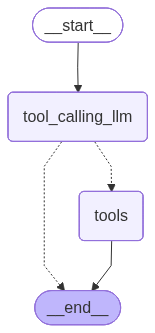

In [26]:
from IPython.display import Image,display
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode, tools_condition

def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]} 


builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition,
)

builder.add_edge("tools",END)

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [27]:
messages = graph.invoke({"messages":HumanMessage(content="Attention is all you need")})

for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Attention is all you need
================================== Ai Message ==================================
Tool Calls:
  arxiv (3c0039145)
 Call ID: 3c0039145
  Args:
    query: Attention is all you need
  wikipedia (6qn6p0he7)
 Call ID: 6qn6p0he7
  Args:
    query: Attention mechanism
  tavily_search_results_json (ws5sfq4gb)
 Call ID: ws5sfq4gb
  Args:
    query: Attention is all you need
================================= Tool Message =================================
Name: arxiv

Published: 2021-05-06
Title: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet
Authors: Luke Melas-Kyriazi
Summary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this

In [28]:
messages = graph.invoke({"messages":HumanMessage(content="Latest AI news")})

for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Latest AI news
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (w70s22sfq)
 Call ID: w70s22sfq
  Args:
    query: Latest AI news
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "AI News | Latest News | Insights Powering AI-Driven Business Growth", "url": "https://www.artificialintelligence-news.com/", "content": "Governance, Regulation & Policy\n\nApril 13, 2026\n\n### IBM: How robust AI governance protects enterprise margins\n\nGovernance, Regulation & Policy\n\nApril 10, 2026\n\n### KPMG: Inside the AI agent playbook driving enterprise margin gains\n\nAI Business Strategy\n\nApril 1, 2026\n\n#### Industries\n\n### Trustpilot partners with AI companies as traditional search declines\n\nRetail & Logistics AI\n\nMarch 17, 2026\n\n### Agentic AI in finance s

In [29]:
messages = graph.invoke({"messages":HumanMessage(content="What is Machine Learning")})

for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is Machine Learning
================================== Ai Message ==================================
Tool Calls:
  wikipedia (7p504dj7z)
 Call ID: 7p504dj7z
  Args:
    query: Machine Learning
================================= Tool Message =================================
Name: wikipedia

Page: Machine learning
Summary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without explicit programming language instructions. Within a subdiscipline of machine learning, advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.
Statistics and mathematical optimisation (mathematical programming) methods compose the foundations of mac

In [30]:
messages = graph.invoke({"messages":HumanMessage(content="Hi I am Vishal Mendhikar")})

for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hi I am Vishal Mendhikar
================================== Ai Message ==================================

Hello Vishal Mendhikar! How can I assist you today? Whether you have questions or need help with something specific, feel free to let me know!
